In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson

Probabilità p: 0.1
Valore atteso (mu): 100.0
Deviazione std (sigma): 9.49


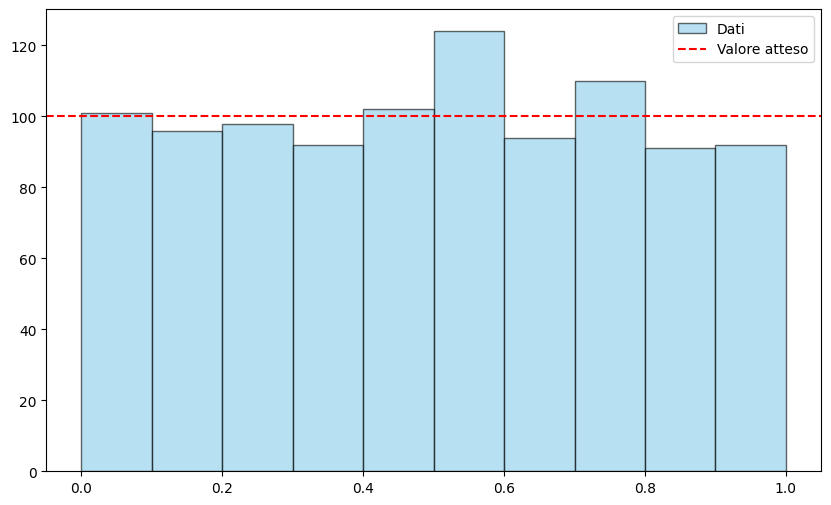

In [7]:
# Parametri iniziali
N = 1000
n_bins = 10

# Generazione dati e istogramma
dati = np.random.uniform(0, 1, N)

plt.figure(figsize=(10, 6))
# 'conteggi' riceve quanti eventi sono finiti in ogni colonna
conteggi, bordi, _ = plt.hist(dati, bins=n_bins, range=(0, 1), color='skyblue', alpha=0.6, label='Dati', edgecolor='black')

# Calcoli
p = 1 / n_bins
mu = N * p
sigma = np.sqrt(N * p * (1 - p))

print(f"Probabilità p: {p}")
print(f"Valore atteso (mu): {mu}")
print(f"Deviazione std (sigma): {sigma:.2f}")

# Linea del valore atteso
plt.axhline(mu, color='red', linestyle='--', label='Valore atteso')
plt.legend()
plt.show()

In [8]:
# Punto 2
M = 1000  # Numero ripetizioni
conteggi_bin = []

# Ciclo
for i in range(M):
    # Genero nuovi dati
    dati_temp = np.random.uniform(0, 1, N)

    # Calcolo istogramma
    conteggi, _ = np.histogram(dati_temp, bins=n_bins, range=(0, 1))

    # Prendo solo il numero di eventi caduti nel 5° bin (indice 4 perché si conta da 0)
    # E lo aggiungo alla mia lista 'conteggi_bin'
    conteggi_bin.append(conteggi[4])


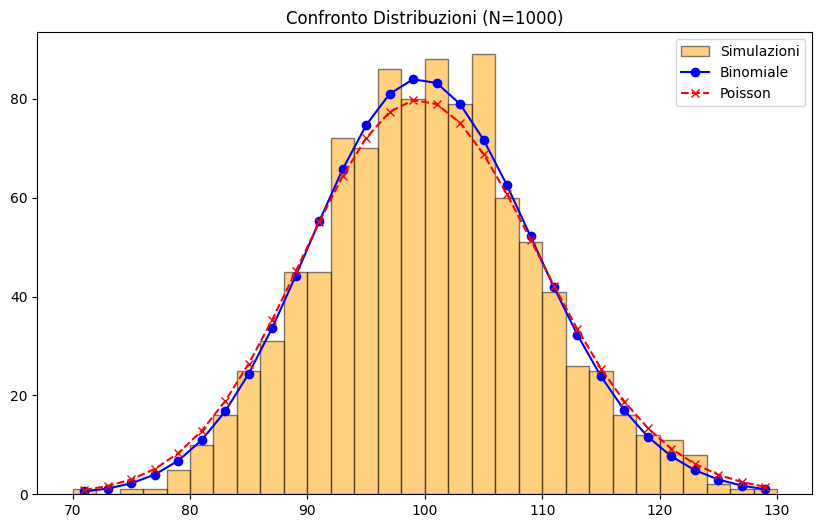

In [9]:
plt.figure(figsize=(10, 6))

# Istogramma dei risultati delle 1000 simulazioni
# Range [70, 130] e 30 bin
h, bordi, _ = plt.hist(conteggi_bin, bins=30, range=(70, 130), alpha=0.5, color='orange', edgecolor='black', label='Simulazioni')

# Calcolo centro dei bin e larghezza per le curve
centri = (bordi[:-1] + bordi[1:]) / 2
delta_x = bordi[1] - bordi[0] # Larghezza del bin (serve per scalare le curve)

# Curva Binomiale (Punto 3)
# binom.pmf calcola la probabilità teorica.
# Moltiplichiamo per M * delta_x per adattare l'altezza della curva all'istogramma dei conteggi.

y_binom = binom.pmf(np.floor(centri), N, p) * M * delta_x # floor serve a rendere intero il numero
plt.plot(centri, y_binom, 'b-o', label='Binomiale') # x; y; stile (blue; solid line; circle)

# Curva Poissoniana (Punto 4)
# La Poisson dipende solo da lambda (valore medio), che qui è N*p
lam = N * p
y_pois = poisson.pmf(np.floor(centri), lam) * M * delta_x
plt.plot(centri, y_pois, 'r--x', label='Poisson')

plt.legend()
plt.title(f'Confronto Distribuzioni (N={N})')
plt.show()

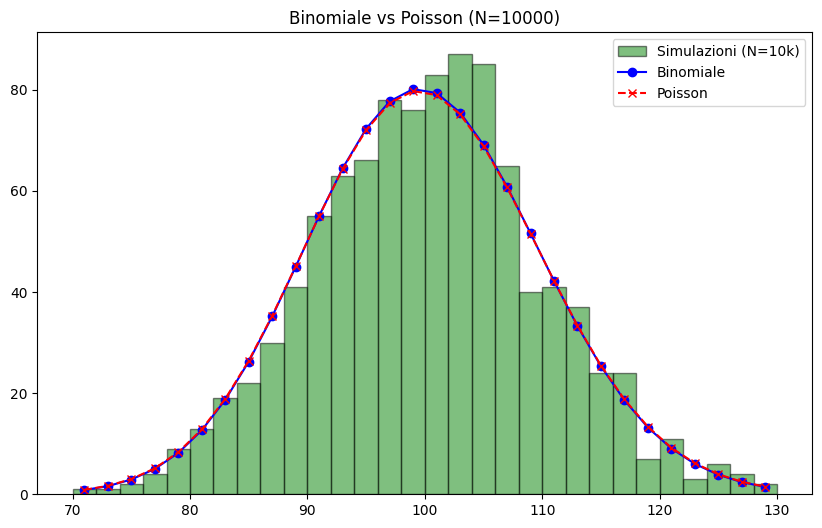

In [10]:
# Punto 5
N_2 = 10000
n_bins_2 = 100
p_2 = 1 / n_bins_2

conteggi_2 = []

# Ripeto la simulazione M volte
for i in range(M):
    dati_temporanei = np.random.uniform(0, 1, N_2)
    conteggi_temp, _ = np.histogram(dati_temporanei, bins=n_bins_2, range=(0, 1))
    conteggi_2.append(conteggi_temp[50])

# Grafico
plt.figure(figsize=(10, 6))

h, bordi, _ = plt.hist(conteggi_2, bins=30, range=(70, 130),
                       alpha=0.5, color='green', edgecolor='black', label='Simulazioni (N=10k)')

centri = (bordi[:-1] + bordi[1:]) / 2 #lati sinistri + destri / 2
delta_x = bordi[1] - bordi[0] #assumendo che abbia bin tutti equispaziati

# Binomiale
y_binom = binom.pmf(np.floor(centri), N_2, p_2) * M * delta_x
plt.plot(centri, y_binom, 'b-o', label='Binomiale')

# Poisson
lambda_2 = N_2 * p_2 # = 100
y_pois = poisson.pmf(np.floor(centri), lambda_2) * M * delta_x
plt.plot(centri, y_pois, 'r--x', label='Poisson')

plt.title('Binomiale vs Poisson (N=10000)')
plt.legend()
plt.show()